# HAT + Deep RCAN V2 Pipeline

Test:
- Direct Improved RCAN: 10 m → 2.5 m
- Cascaded HAT + Deep RCAN V2: 10 m → 5 m → 1.25 m

All models use 4 Sentinel-2 bands.

In [1]:
!pip install -q tacoreader

In [2]:
import os
import gc
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import rasterio
import tacoreader.v1 as tacoreader

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


In [3]:
dataset = tacoreader.load("tacofoundation:sen2naipv2-unet")

NORMALIZATION = 3000.0
SCALE = 4

TEST_INDICES = list(range(150, 160))

print("Test samples:", len(TEST_INDICES))

Test samples: 10


## Improved RCAN Architecture

12 Residual Channel Attention Blocks  
96 feature channels  
4 input bands → 4 output bands  
×4 PixelShuffle upsampling

In [6]:
import glob

checkpoint_candidates = glob.glob(
    "/kaggle/input/**/rcan_improved.pth",
    recursive=True
)

print(checkpoint_candidates)

['/kaggle/input/models/nakulhemantkarpe/rcan-final/pytorch/default/1/rcan_improved.pth']


In [7]:

rcan_checkpoint_path = checkpoint_candidates[0]

checkpoint = torch.load(
    rcan_checkpoint_path,
    map_location="cpu",
    weights_only=False
)

print("Checkpoint loaded")
print(checkpoint.keys())


Checkpoint loaded
dict_keys(['model_name', 'model_state_dict', 'num_blocks', 'channels', 'scale', 'num_bands', 'normalization', 'patch_size', 'epochs', 'RMSE', 'PSNR', 'SSIM'])


In [8]:
class RCAB(nn.Module):
    def __init__(self, channels=96, reduction=8):
        super().__init__()

        self.conv1 = nn.Conv2d(
            channels, channels, 3, padding=1
        )

        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            channels, channels, 3, padding=1
        )

        self.attention = nn.Sequential(
            nn.Conv2d(
                channels,
                channels // reduction,
                1
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                channels // reduction,
                channels,
                1
            ),
            nn.Sigmoid()
        )

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.relu(out)
        out = self.conv2(out)

        attention = F.adaptive_avg_pool2d(out, 1)
        attention = self.attention(attention)

        out = out * attention

        return residual + 0.1 * out


class ImprovedRCAN(nn.Module):
    def __init__(
        self,
        scale=4,
        channels=96,
        num_blocks=12,
        num_bands=4
    ):
        super().__init__()

        self.head = nn.Conv2d(
            num_bands,
            channels,
            3,
            padding=1
        )

        self.body = nn.Sequential(
            *[
                RCAB(channels)
                for _ in range(num_blocks)
            ]
        )

        self.body_conv = nn.Conv2d(
            channels,
            channels,
            3,
            padding=1
        )

        self.up1 = nn.Sequential(
            nn.Conv2d(
                channels,
                channels * 4,
                3,
                padding=1
            ),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True)
        )

        self.up2 = nn.Sequential(
            nn.Conv2d(
                channels,
                channels * 4,
                3,
                padding=1
            ),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True)
        )

        self.tail = nn.Conv2d(
            channels,
            num_bands,
            3,
            padding=1
        )

    def forward(self, x):
        shallow = self.head(x)

        x = self.body(shallow)
        x = self.body_conv(x)
        x = x + shallow

        x = self.up1(x)
        x = self.up2(x)

        return self.tail(x)


model = ImprovedRCAN(
    scale=4,
    channels=96,
    num_blocks=12,
    num_bands=4
).to(device)

model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=True
)

model.eval()

print("Improved RCAN loaded successfully.")
print(
    f"Parameters: "
    f"{sum(p.numel() for p in model.parameters()):,}"
)

Improved RCAN loaded successfully.
Parameters: 2,776,276


In [9]:
def read_pair(index):
    sample = dataset.read(index)

    lr_path = sample.read(0)
    hr_path = sample.read(1)

    with rasterio.open(lr_path) as src:
        lr = src.read().astype(np.float32)

    with rasterio.open(hr_path) as src:
        hr = src.read().astype(np.float32)

    lr /= NORMALIZATION
    hr /= NORMALIZATION

    return lr, hr


lr, hr = read_pair(TEST_INDICES[0])

print("LR shape:", lr.shape)
print("HR shape:", hr.shape)

LR shape: (4, 130, 130)
HR shape: (4, 520, 520)


In [10]:
lr, hr = read_pair(TEST_INDICES[0])

lr_tensor = torch.from_numpy(lr).unsqueeze(0).float().to(device)

with torch.no_grad():
    prediction = model(lr_tensor)

prediction = prediction.squeeze(0).cpu().numpy()

print("LR shape   :", lr.shape)
print("HR shape   :", hr.shape)
print("Prediction :", prediction.shape)
print("LR range   :", lr.min(), "→", lr.max())
print("Pred range :", prediction.min(), "→", prediction.max())
print("HR range   :", hr.min(), "→", hr.max())

LR shape   : (4, 130, 130)
HR shape   : (4, 520, 520)
Prediction : (4, 520, 520)
LR range   : 0.072 → 1.8573333
Pred range : 0.025700288 → 2.4387455
HR range   : 0.037333332 → 1.96


In [11]:

lr_tensor = torch.from_numpy(lr).unsqueeze(0).float().to(device)

with torch.no_grad():
    prediction = model(lr_tensor)

prediction = prediction.squeeze(0).cpu().numpy()

print("Input shape :", lr_tensor.shape)
print("Output shape:", prediction.shape)

Input shape : torch.Size([1, 4, 130, 130])
Output shape: (4, 520, 520)


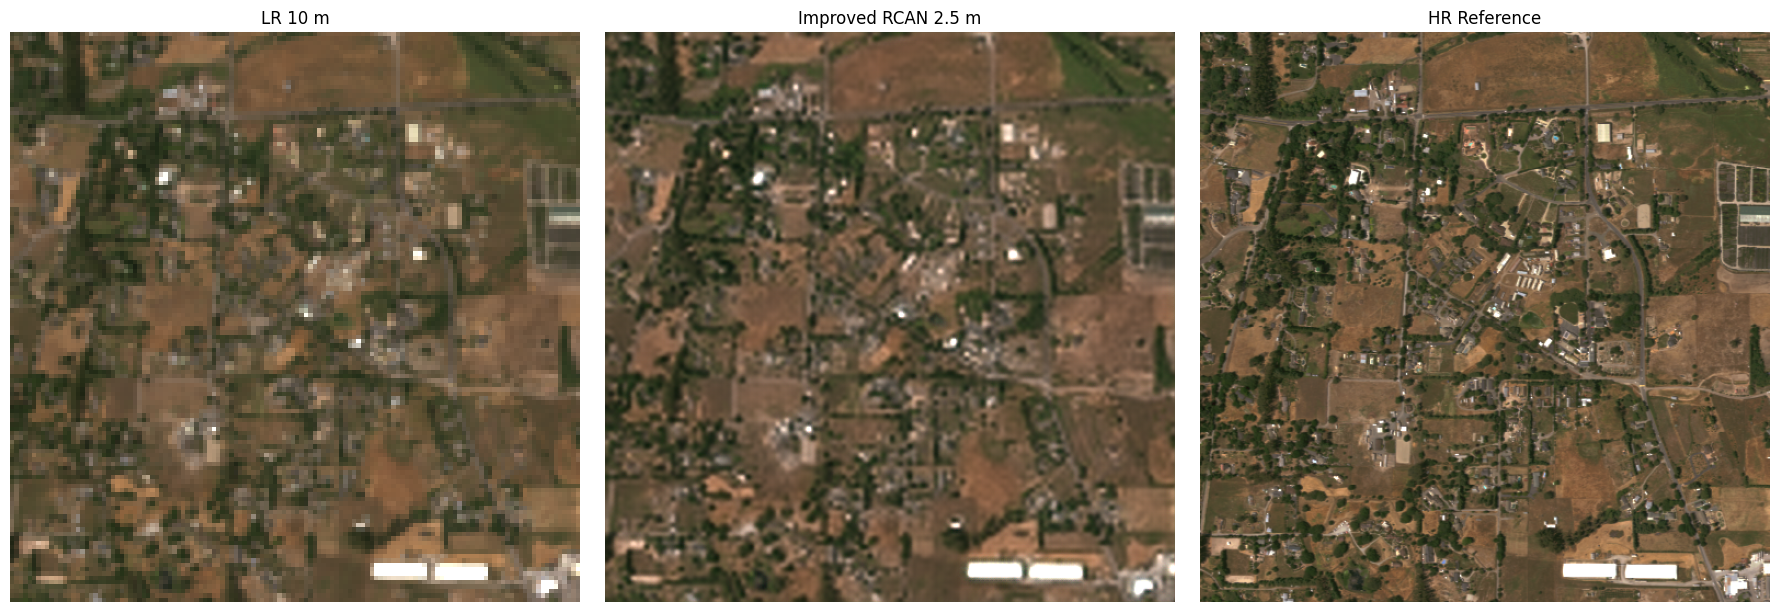

In [12]:
def display_rgb(x):
    x = np.clip(x, 0, 1)
    return np.transpose(x[:3], (1, 2, 0))


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(display_rgb(lr))
axes[0].set_title("LR 10 m")

axes[1].imshow(display_rgb(prediction))
axes[1].set_title("Improved RCAN 2.5 m")

axes[2].imshow(display_rgb(hr))
axes[2].set_title("HR Reference")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [14]:
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F

hat_candidates = glob.glob(
    "/kaggle/input/**/stage1_residual_hat_final.pth",
    recursive=True
)

print(hat_candidates)

['/kaggle/input/models/nakulhemantkarpe/rcan-hat-final/transformers/default/1/stage1_residual_hat_final.pth']


In [15]:
hat_checkpoint_path = hat_candidates[0]

hat_checkpoint = torch.load(
    hat_checkpoint_path,
    map_location="cpu",
    weights_only=False
)

print(hat_checkpoint.keys())

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'val_rmse'])


In [30]:
class ChannelAttention(nn.Module):
    def __init__(self, channels=48, reduction=8):
        super().__init__()

        self.body = nn.Sequential(
            nn.Conv2d(
                channels,
                channels // reduction,
                1
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                channels // reduction,
                channels,
                1
            )
        )

    def forward(self, x):
        weights = self.body(
            F.adaptive_avg_pool2d(x, 1)
        )

        weights = torch.sigmoid(weights)

        return x * weights

In [31]:
class ResidualHAT(nn.Module):
    def __init__(
        self,
        channels=48,
        num_blocks=3,
        num_heads=4,
        window_size=8
    ):
        super().__init__()

        self.head = nn.Conv2d(
            4,
            channels,
            3,
            padding=1
        )

        self.body = nn.Sequential(
            *[
                HATBlock(
                    channels=channels,
                    num_heads=num_heads,
                    window_size=window_size
                )
                for _ in range(num_blocks)
            ]
        )

        self.channel_attention = ChannelAttention(
            channels=channels,
            reduction=8
        )

        self.body_conv = nn.Conv2d(
            channels,
            channels,
            3,
            padding=1
        )

        self.up = nn.Sequential(
            nn.Conv2d(
                channels,
                channels * 4,
                3,
                padding=1
            ),
            nn.PixelShuffle(2),
            nn.ReLU(inplace=True)
        )

        self.tail = nn.Conv2d(
            channels,
            4,
            3,
            padding=1
        )

    def forward(self, x):
        base = F.interpolate(
            x,
            scale_factor=2,
            mode="bicubic",
            align_corners=False
        )

        shallow = self.head(x)

        features = self.body(shallow)

        features = self.channel_attention(
            features
        )

        features = self.body_conv(features)

        features = features + shallow

        features = self.up(features)

        residual = self.tail(features)

        return base + residual

In [32]:
hat_model = ResidualHAT(
    channels=48,
    num_blocks=3,
    num_heads=4,
    window_size=8
).to(device)

hat_model.load_state_dict(
    hat_checkpoint["model_state_dict"],
    strict=True
)

hat_model.eval()

print("Residual HAT loaded successfully")
print(
    f"Parameters: "
    f"{sum(p.numel() for p in hat_model.parameters()):,}"
)

Residual HAT loaded successfully
Parameters: 192,874


In [33]:
lr, hr = read_pair(150)

lr_tensor = torch.from_numpy(
    lr
).unsqueeze(0).float().to(device)

with torch.no_grad():
    hat_output = hat_model(
        lr_tensor
    )

hat_output = (
    hat_output
    .squeeze(0)
    .cpu()
    .numpy()
)

print("LR :", lr.shape)
print("HAT:", hat_output.shape)
print("HR :", hr.shape)

LR : (4, 130, 130)
HAT: (4, 260, 260)
HR : (4, 520, 520)


In [34]:
with torch.no_grad():
    bicubic = F.interpolate(
        lr_tensor,
        scale_factor=2,
        mode="bicubic",
        align_corners=False
    )

bicubic = bicubic.squeeze(0).cpu().numpy()

print("Bicubic:", bicubic.shape)
print("HAT    :", hat_output.shape)

Bicubic: (4, 260, 260)
HAT    : (4, 260, 260)


In [35]:
def stretch_rgb(x, low=2, high=98):
    rgb = x[[2, 1, 0]]
    rgb = np.transpose(rgb, (1, 2, 0))

    lo = np.percentile(rgb, low)
    hi = np.percentile(rgb, high)

    rgb = (rgb - lo) / (hi - lo + 1e-8)

    return np.clip(rgb, 0, 1)

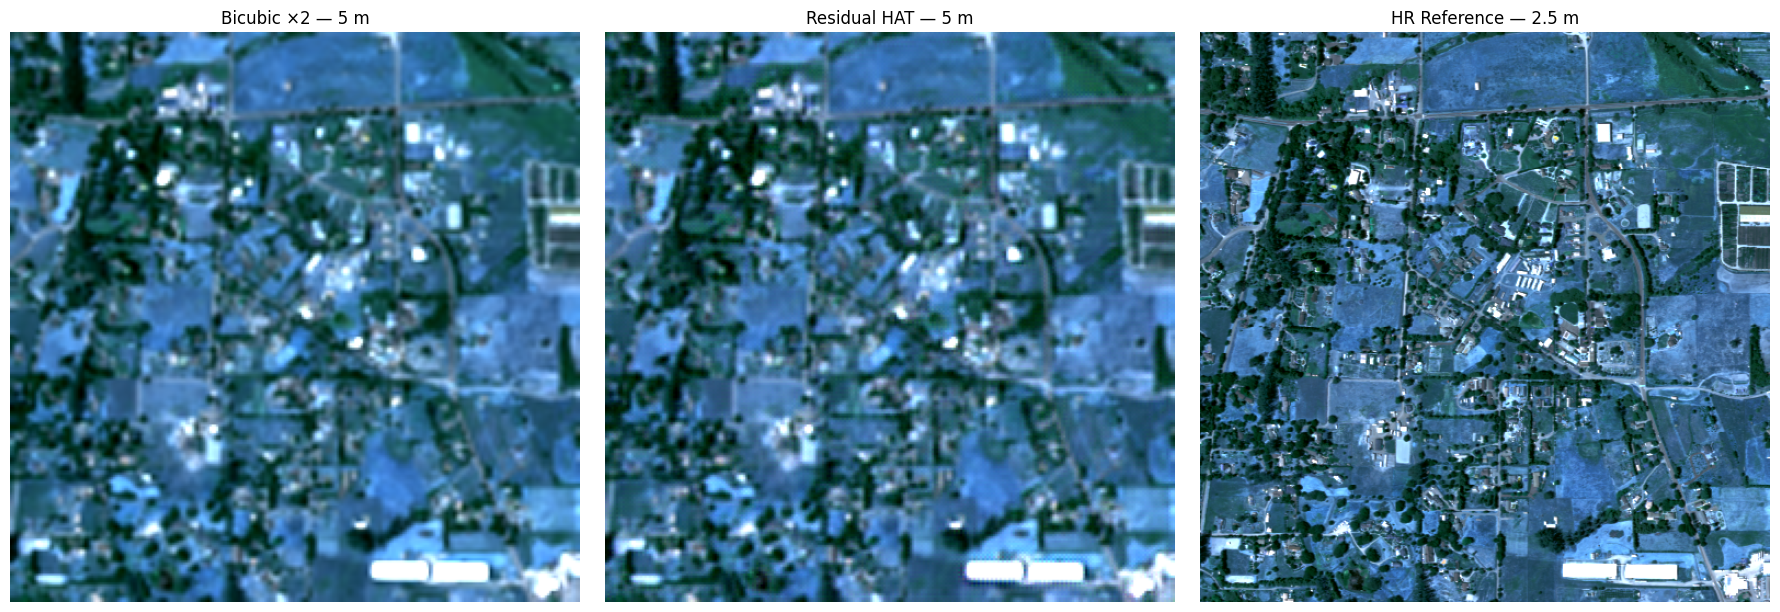

In [37]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6)
)

axes[0].imshow(
    stretch_rgb(bicubic)
)
axes[0].set_title("Bicubic ×2 — 5 m")

axes[1].imshow(
    stretch_rgb(hat_output)
)
axes[1].set_title("Residual HAT — 5 m")

axes[2].imshow(
    stretch_rgb(hr)
)
axes[2].set_title("HR Reference — 2.5 m")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [38]:
lr_tensor = torch.from_numpy(
    lr
).unsqueeze(0).float().to(device)

with torch.no_grad():
    hat_sr = hat_model(lr_tensor)

print("HAT output:", hat_sr.shape)

hat_down = F.interpolate(
    hat_sr,
    size=lr.shape[-2:],
    mode="bicubic",
    align_corners=False
)

print("RCAN input:", hat_down.shape)

with torch.no_grad():
    final_sr = model(hat_down)

print("Final output:", final_sr.shape)

HAT output: torch.Size([1, 4, 260, 260])
RCAN input: torch.Size([1, 4, 130, 130])
Final output: torch.Size([1, 4, 520, 520])


In [39]:
hat_sr = hat_sr.squeeze(0).cpu().numpy()
hat_down = hat_down.squeeze(0).cpu().numpy()
final_sr = final_sr.squeeze(0).cpu().numpy()

print("LR       :", lr.shape)
print("HAT      :", hat_sr.shape)
print("HAT down :", hat_down.shape)
print("Final SR :", final_sr.shape)
print("HR       :", hr.shape)

LR       : (4, 130, 130)
HAT      : (4, 260, 260)
HAT down : (4, 130, 130)
Final SR : (4, 520, 520)
HR       : (4, 520, 520)


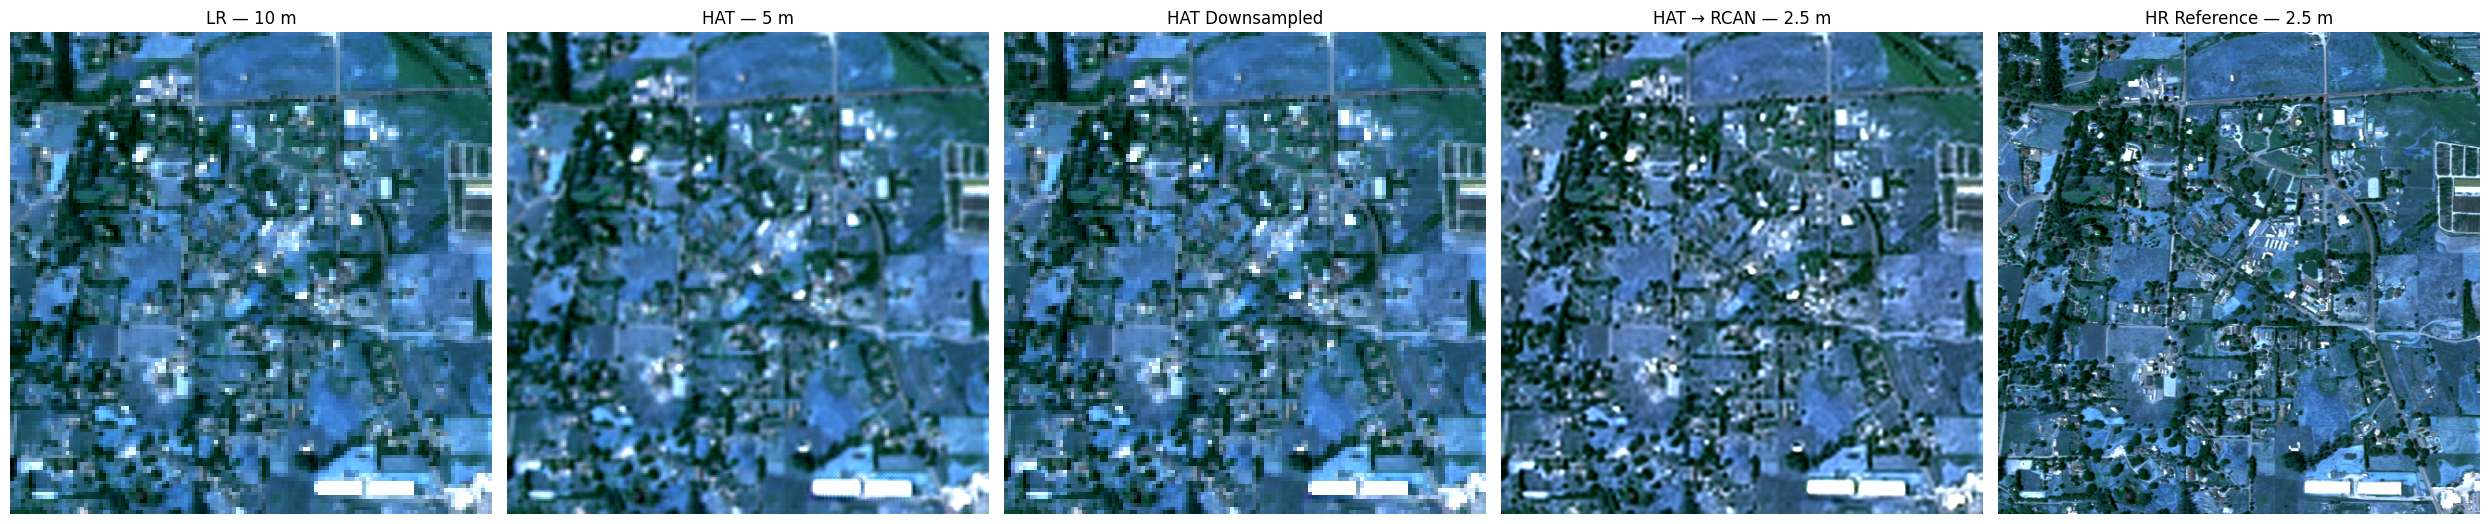

In [41]:
fig, axes = plt.subplots(
    1, 5,
    figsize=(25, 6)
)

axes[0].imshow(stretch_rgb(lr))
axes[0].set_title("LR — 10 m")

axes[1].imshow(stretch_rgb(hat_sr))
axes[1].set_title("HAT — 5 m")

axes[2].imshow(stretch_rgb(hat_down))
axes[2].set_title("HAT Downsampled")

axes[3].imshow(stretch_rgb(final_sr))
axes[3].set_title("HAT → RCAN — 2.5 m")

axes[4].imshow(stretch_rgb(hr))
axes[4].set_title("HR Reference — 2.5 m")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

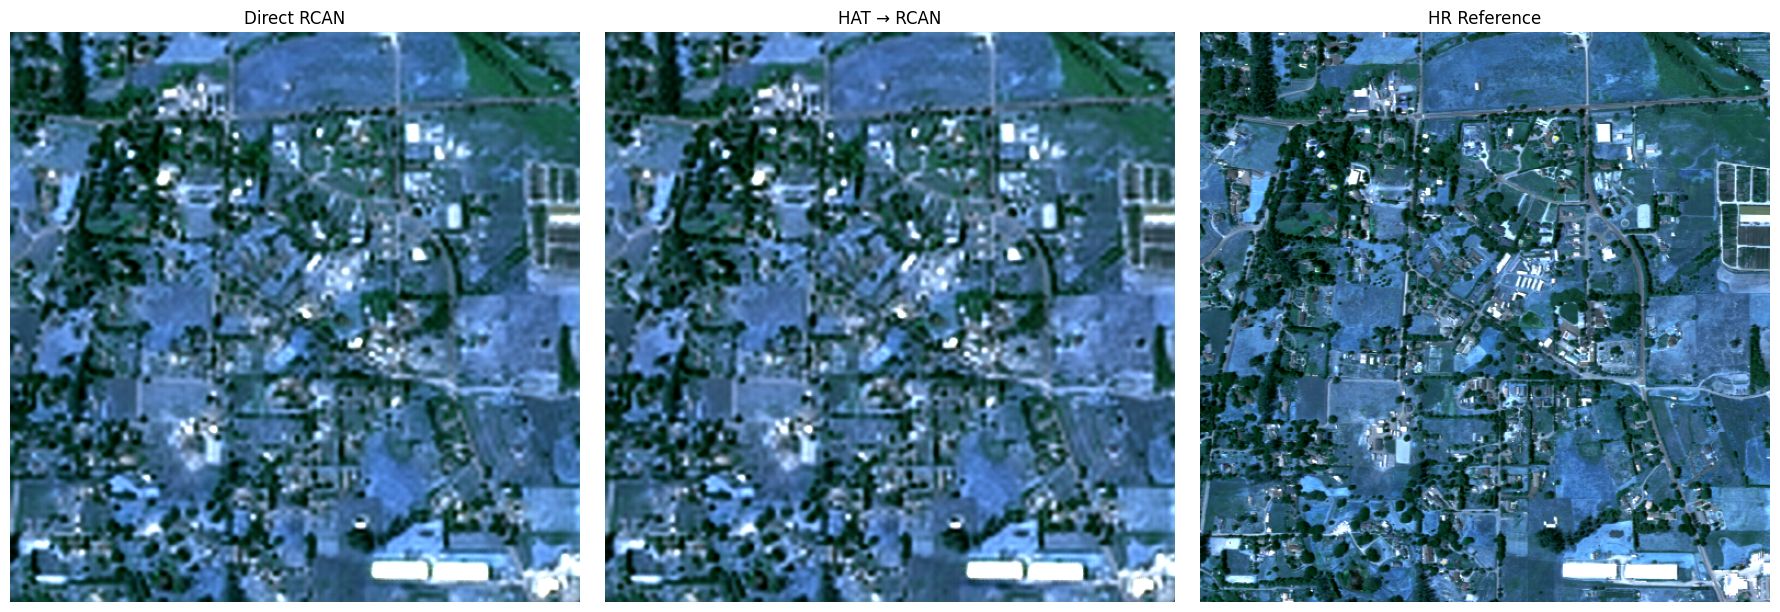

In [42]:
with torch.no_grad():
    direct_rcan = model(
        lr_tensor
    )

direct_rcan = (
    direct_rcan
    .squeeze(0)
    .cpu()
    .numpy()
)

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6)
)

axes[0].imshow(
    stretch_rgb(direct_rcan)
)
axes[0].set_title("Direct RCAN")

axes[1].imshow(
    stretch_rgb(final_sr)
)
axes[1].set_title("HAT → RCAN")

axes[2].imshow(
    stretch_rgb(hr)
)
axes[2].set_title("HR Reference")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [43]:
from skimage.metrics import structural_similarity
from math import sqrt

In [44]:
def calculate_metrics(pred, target):
    pred = np.clip(pred, 0, 1)
    target = np.clip(target, 0, 1)

    mse = np.mean((pred - target) ** 2)
    rmse = np.sqrt(mse)

    psnr = 20 * np.log10(1.0 / (rmse + 1e-12))

    ssim_values = []

    for band in range(pred.shape[0]):
        ssim_values.append(
            structural_similarity(
                target[band],
                pred[band],
                data_range=1.0
            )
        )

    ssim = np.mean(ssim_values)

    return rmse, psnr, ssim

In [46]:
direct_rmse, direct_psnr, direct_ssim = calculate_metrics(
    direct_rcan,
    hr
)

cascade_rmse, cascade_psnr, cascade_ssim = calculate_metrics(
    final_sr,
    hr
)

print("Direct RCAN")
print(f"RMSE : {direct_rmse:.6f}")
print(f"PSNR : {direct_psnr:.4f} dB")
print(f"SSIM : {direct_ssim:.4f}")

print("\nHAT → RCAN")
print(f"RMSE : {cascade_rmse:.6f}")
print(f"PSNR : {cascade_psnr:.4f} dB")
print(f"SSIM : {cascade_ssim:.4f}")

Direct RCAN
RMSE : 0.055780
PSNR : 25.0704 dB
SSIM : 0.7180

HAT → RCAN
RMSE : 0.057201
PSNR : 24.8519 dB
SSIM : 0.7197


In [47]:
print("Improvement: HAT → RCAN over Direct RCAN")
print(
    f"RMSE change : {direct_rmse - cascade_rmse:+.6f}"
)
print(
    f"PSNR change : {cascade_psnr - direct_psnr:+.4f} dB"
)
print(
    f"SSIM change : {cascade_ssim - direct_ssim:+.4f}"
)

Improvement: HAT → RCAN over Direct RCAN
RMSE change : -0.001421
PSNR change : -0.2185 dB
SSIM change : +0.0016


# Experiment Note — HAT → RCAN Cascade

### Objective

To investigate whether a **Residual HAT ×2 stage** could improve the performance of the existing **Improved RCAN ×4** super-resolution model by using HAT as a feature-refinement stage before RCAN.

### Pipeline Tested

**Sentinel-2 LR (10 m)**
→ **Residual HAT ×2 (5 m)**
→ Bicubic downsampling to original LR size
→ **Improved RCAN ×4**
→ **2.5 m SR output**

The HAT checkpoint was successfully reconstructed and loaded with **192,874 parameters**. The resulting HAT output produced visually valid imagery after correcting the residual architecture and channel-attention implementation.

### Results

| Model             |       RMSE ↓ |         PSNR ↑ |     SSIM ↑ |
| ----------------- | -----------: | -------------: | ---------: |
| **Improved RCAN** | **0.055780** | **25.0704 dB** |     0.7180 |
| **HAT → RCAN**    |     0.057201 |     24.8519 dB | **0.7197** |

### Observation

The HAT → RCAN cascade produced a very small **SSIM improvement of +0.0017**, indicating a slight structural similarity benefit. However, this came at the cost of:

* **RMSE:** +0.001421
* **PSNR:** −0.2185 dB

Therefore, HAT did **not provide a sufficiently meaningful overall improvement** over the existing Improved RCAN.

### Decision

**Improved RCAN is selected as the MVP model.**

The HAT experiment will be retained as an **ablation/experimental result**, demonstrating that an additional transformer-based refinement stage was investigated but did not outperform the simpler RCAN pipeline on the current evaluation.

### Final MVP

**10 m Sentinel-2 → Improved RCAN → 2.5 m 4-band super-resolved imagery**

This keeps the MVP simpler, computationally lighter, and supported by the stronger **RMSE and PSNR** results.
